In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

from mlxtend.frequent_patterns import apriori, association_rules

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [2]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float64
 11  Popu

In [4]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df["Air_Pollution_Level"] = pd.cut(
    df["Air_Pollution_Index"],
    bins=[0,30,60,100],
    labels=["Low","Medium","High"]
)

df["Water_Pollution_Level"] = pd.cut(
    df["Water_Pollution_Index"],
    bins=[0,30,60,100],
    labels=["Low","Medium","High"]
)

df["Soil_Pollution_Level"] = pd.cut(
    df["Soil_Pollution_Index"],
    bins=[0,30,60,100],
    labels=["Low","Medium","High"]
)

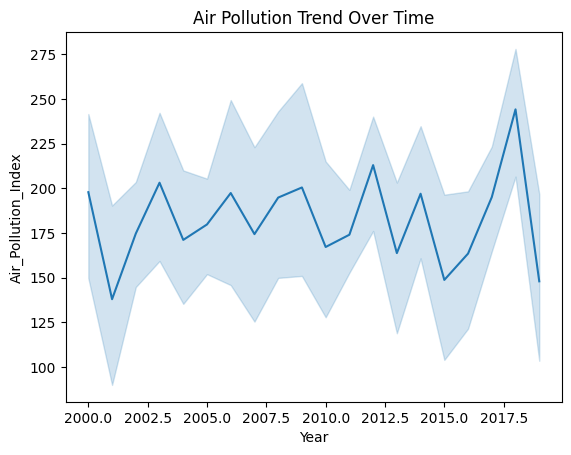

In [7]:
plt.figure()

sns.lineplot(data=df, x="Year", y="Air_Pollution_Index")

plt.title("Air Pollution Trend Over Time")

plt.show()

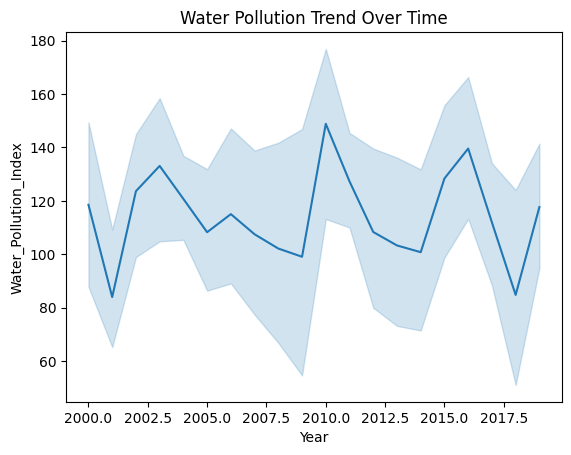

In [8]:
plt.figure()

sns.lineplot(data=df, x="Year", y="Water_Pollution_Index")

plt.title("Water Pollution Trend Over Time")

plt.show()

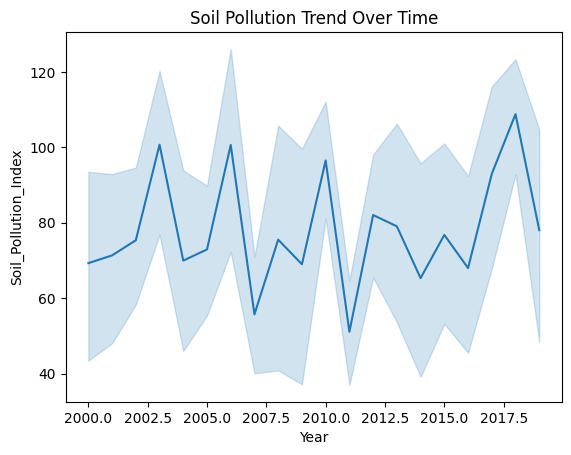

In [9]:
plt.figure()

sns.lineplot(data=df, x="Year", y="Soil_Pollution_Index")

plt.title("Soil Pollution Trend Over Time")

plt.show()

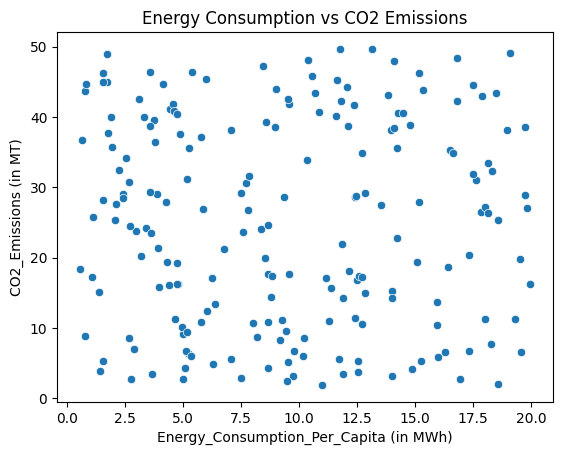

In [10]:
plt.figure()

sns.scatterplot(
    data=df,
    x="Energy_Consumption_Per_Capita (in MWh)",
    y="CO2_Emissions (in MT)"
)

plt.title("Energy Consumption vs CO2 Emissions")

plt.show()

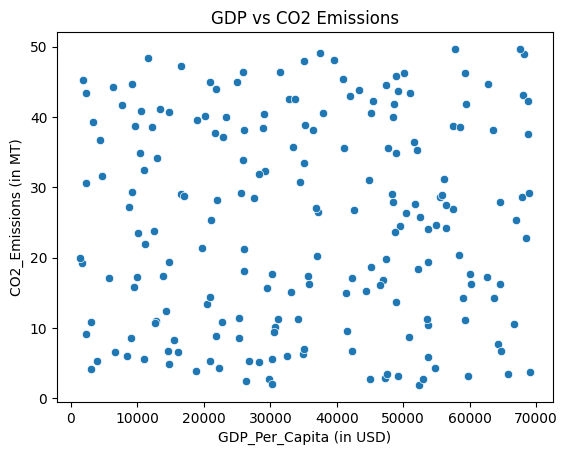

In [11]:
plt.figure()

sns.scatterplot(
    data=df,
    x="GDP_Per_Capita (in USD)",
    y="CO2_Emissions (in MT)"
)

plt.title("GDP vs CO2 Emissions")

plt.show()

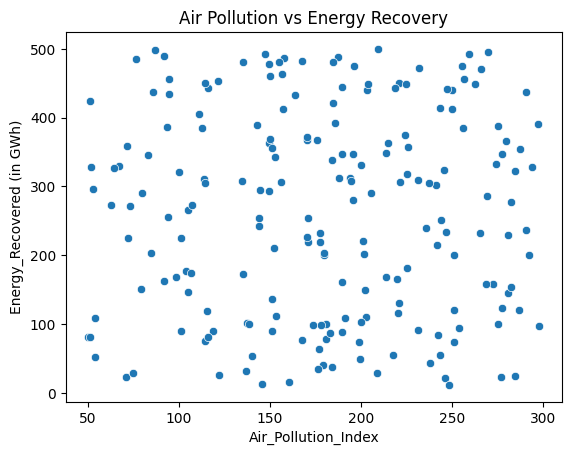

In [12]:
plt.figure()

sns.scatterplot(
    data=df,
    x="Air_Pollution_Index",
    y="Energy_Recovered (in GWh)"
)

plt.title("Air Pollution vs Energy Recovery")

plt.show()

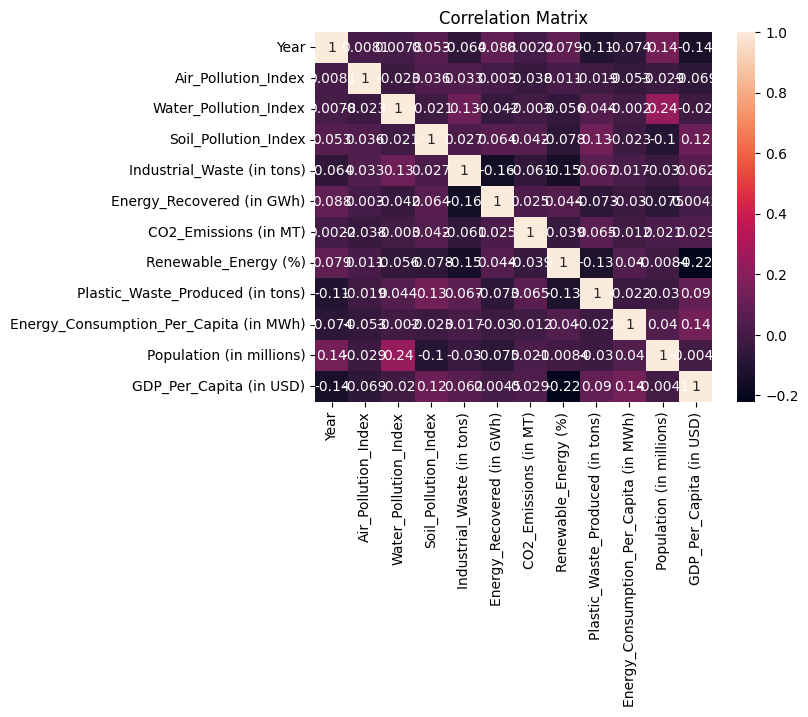

In [13]:
corr = df.corr(numeric_only=True)

plt.figure()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

In [14]:
apriori_df = df[[
    "Air_Pollution_Level",
    "Water_Pollution_Level",
    "Soil_Pollution_Level"
]]

apriori_df = pd.get_dummies(apriori_df)

In [15]:
frequent_itemsets = apriori(
    apriori_df,
    min_support=0.1,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.110,frozenset({Air_Pollution_Level_High})
1,0.150,frozenset({Water_Pollution_Level_Medium})
2,0.260,frozenset({Water_Pollution_Level_High})
3,0.155,frozenset({Soil_Pollution_Level_Low})
4,0.215,frozenset({Soil_Pollution_Level_Medium})


In [16]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


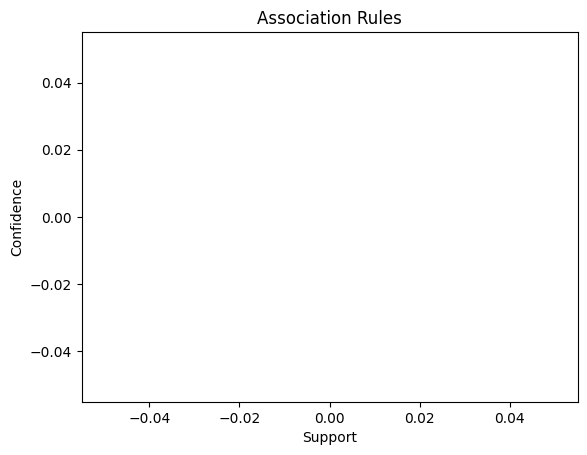

In [17]:
plt.scatter(rules["support"], rules["confidence"])

plt.xlabel("Support")

plt.ylabel("Confidence")

plt.title("Association Rules")

plt.show()

In [18]:
train, test = train_test_split(
    apriori_df,
    test_size=0.2,
    random_state=42
)

In [19]:
freq_train = apriori(
    train,
    min_support=0.1,
    use_colnames=True
)

rules_train = association_rules(
    freq_train,
    metric="confidence",
    min_threshold=0.6
)

rules_train.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [20]:
df["High_CO2"] = (
    df["CO2_Emissions (in MT)"]
    > df["CO2_Emissions (in MT)"].median()
).astype(int)

In [21]:
features = df[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Energy_Consumption_Per_Capita (in MWh)"
]]

labels = df["High_CO2"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [24]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [25]:
model = Sequential()

model.add(Conv1D(32, 2, activation="relu", input_shape=(X_train.shape[1],1)))

model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(64, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10


c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: Dep

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4812 - loss: 0.7016 - val_accuracy: 0.4750 - val_loss: 0.7067
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4625 - loss: 0.6978 - val_accuracy: 0.4750 - val_loss: 0.7045
Epoch 3/10


c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4688 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.7035
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4563 - loss: 0.6939 - val_accuracy: 0.4250 - val_loss: 0.7026
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5125 - loss: 0.6929 - val_accuracy: 0.4500 - val_loss: 0.7018
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5875 - loss: 0.6908 - val_accuracy: 0.4250 - val_loss: 0.7014
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5562 - loss: 0.6899 - val_accuracy: 0.4500 - val_loss: 0.7017
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5813 - loss: 0.6888 - val_accuracy: 0.4750 - val_loss: 0.7024
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5750 - loss: 0.6879 - val_accuracy: 0.5000 - val_loss: 0.7028
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5750 - loss: 0.6867 - val_accuracy: 0.5000 - val_loss: 0.7031


In [28]:
pred = model.predict(X_test)

pred_labels = (pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


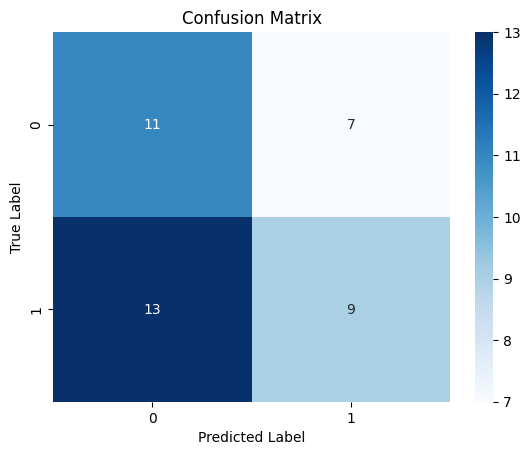

In [32]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

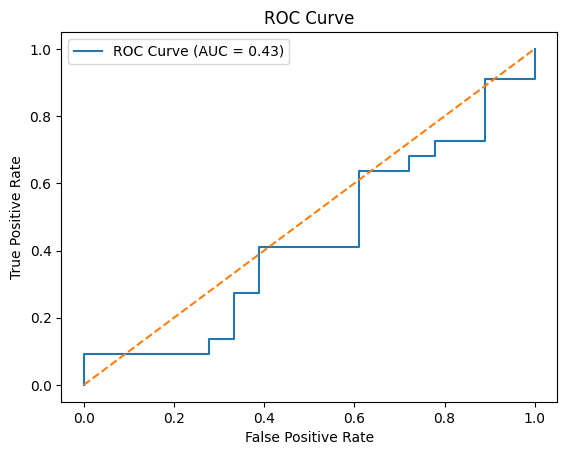

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, pred.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [31]:
loss, accuracy = model.evaluate(X_test, y_test)


print("Model Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5000 - loss: 0.7031
Model Accuracy: 0.5


# Phase 4 – Reporting and Insights

---

## Model Comparison

This project applied two different analytical approaches to study pollution patterns and emission prediction: the Apriori association rule mining algorithm and a Convolutional Neural Network (CNN) classification model.

### CNN Model

The CNN model was used as a predictive model to classify high CO₂ emission scenarios based on environmental indicators such as air pollution, water pollution, soil pollution, and energy consumption per capita.

The CNN architecture consisted of:

- A 1D convolutional layer to extract patterns from pollution indicators  
- A max pooling layer to reduce feature dimensionality  
- A flatten layer to convert features into a dense format  
- Fully connected dense layers for classification  

The model was evaluated using several performance metrics including:

- Confusion Matrix  
- ROC Curve  
- Area Under the Curve (AUC)  
- Model Accuracy  

These metrics help assess the model’s ability to correctly predict high-emission scenarios and evaluate the reliability of the predictions.

---

### Apriori Algorithm

The Apriori algorithm was applied to discover hidden associations between pollution severity levels. Pollution indicators were first categorized into severity levels (Low, Medium, High), and association rules were generated to identify frequent patterns among these categories.

The Apriori algorithm identifies relationships between pollution variables using three main metrics:

- **Support** – Frequency of occurrence of a rule in the dataset  
- **Confidence** – Likelihood that a rule is correct given the antecedent  
- **Lift** – Strength of association between variables  

The association rules revealed patterns showing how different pollution types tend to occur together across countries and time periods.

---

## Comparative Analysis

Both models serve different analytical purposes in the study.

- The **CNN model** focuses on prediction, helping identify situations where high CO₂ emissions are likely based on environmental factors.  
- The **Apriori algorithm** focuses on pattern discovery, identifying relationships between pollution indicators and environmental conditions.

While CNN provides predictive insights using machine learning techniques, Apriori provides interpretable rule-based insights that help understand underlying environmental relationships.

Together, these approaches provide a more comprehensive understanding of pollution dynamics and energy recovery patterns.

---

## Strategic Insights and Recommendations

Based on the analysis conducted in this project, several key insights can be drawn:

1. Higher energy consumption per capita is generally associated with higher CO₂ emissions, indicating that energy-intensive economies contribute more significantly to environmental pollution.

2. Pollution indicators such as air, water, and soil pollution often show correlated patterns, suggesting that industrial and economic activities impact multiple environmental dimensions simultaneously.

3. The Apriori association rules indicate that high pollution levels in one environmental domain often correspond with elevated levels in other domains.

4. Increasing the adoption of renewable energy sources may help reduce long-term emissions and mitigate pollution trends.

5. Energy recovery technologies have the potential to reduce waste and improve environmental sustainability.

---

## Conclusion

This project demonstrated how data mining and machine learning techniques can be applied to analyze global pollution data and environmental indicators.

The Apriori algorithm successfully uncovered hidden relationships between pollution variables, while the CNN model provided predictive capability for identifying high-emission scenarios.

By combining rule-based learning with predictive modeling, the study offers valuable insights that can support environmental policy development, pollution monitoring strategies, and sustainable energy planning.